# ASTR 457: Foundations of Data Science in Astronomy

**Fall 2026 — University of Illinois Urbana-Champaign**

Prof. Gautham Narayan | TA: Abha Vishwakarma

Tue Aug 25, 2026 — Day 1: what this course is, and how it treats AI

Course repo (everything lives here, there is no Canvas): <https://github.com/gnarayan/ast457_2026_Fall>

<img src="images/uiuc_logo.png" alt="University of Illinois Urbana-Champaign wordmark" width="220" style="display:block;margin:0 auto;">

## What this course covers

A survey of the statistical techniques that modern astrophysics actually runs on:

- robust statistics, regression, model building, hypothesis testing
- MCMC and Bayesian inference, parameter estimation
- time series, Gaussian processes, hierarchical models
- machine learning: trees, clustering, dimensionality reduction
- neural networks, foundation models — and the large language models you are already using

Realistic problems, real datasets, and the implicit assumptions behind every method.

<p align="center"><img src="images/data_science_venn.png" alt="Venn diagram: data science sits at the intersection of computer science, math and statistics, and domain knowledge" style="display:block;margin:0 auto;max-height:330px"></p>

## Astronomy became a data science

When I was a student, you could know every object you studied personally. That world is gone:

- The NSF-DOE Vera C. Rubin Observatory is now scanning the entire southern sky every few nights — on the order of **ten million alerts every single night**, for a decade.
- NASA's Roman Space Telescope and ESA's Euclid mission are surveying from space at the same time.
- No human will ever look at more than a vanishing fraction of these data. Every discovery you will make in your career is mediated by a pipeline, a statistic, or a model.

If you can't reason about what the statistics and the models are doing, you are not analyzing the sky — you are analyzing the software's opinion of the sky.

## This is the machine

<p align="center"><img src="images/rubin_observatory.jpg" alt="The NSF-DOE Vera C. Rubin Observatory dome on Cerro Pachon at sunset" style="display:block;margin:0 auto;max-height:480px"></p>

<small>NSF-DOE Vera C. Rubin Observatory, Cerro Pachón, Chile. Credit: O. Bonin/SLAC National Accelerator Laboratory (CC BY 4.0)</small>

## One LSSTCam image

<p align="center"><img src="images/rubin_first_look.jpg" alt="The Cosmic Treasure Chest: a Rubin Observatory First Look image of the southern Virgo cluster, dense with thousands of galaxies" style="display:block;margin:0 auto;max-height:440px"></p>

<small>Rubin First Look, southern Virgo cluster — roughly 10 million galaxies in this one image. Credit: NSF-DOE Vera C. Rubin Observatory/NOIRLab/SLAC/AURA (CC BY 4.0)</small>

## What "deeper" buys you — and who else is digging

<p align="center">
<img src="images/sdss_vs_lsst_depth.png" alt="The same sky field seen by SDSS in 1.5 arcsecond seeing and by Subaru at near-LSST depth: far more, far fainter galaxies appear" style="max-height:330px">
<img src="images/roman_telescope.jpg" alt="Rendering of NASA's Nancy Grace Roman Space Telescope" style="max-height:200px">
<img src="images/euclid.jpg" alt="ESA Euclid image of the Perseus galaxy cluster, hundreds of cluster galaxies and thousands more behind them" style="max-height:200px">
</p>

<small>Left: same field, SDSS vs Subaru at near-LSST depth (credit: Ž. Ivezić). Right: NASA's Roman Space Telescope (credit: NASA GSFC) and ESA's Euclid view of the Perseus cluster (credit: ESA/Euclid/Euclid Consortium/NASA, J.-C. Cuillandre, G. Anselmi, CC BY-SA 3.0 IGO).</small>

## ...and then data science became automated

That was the state of play by ~2020, and this course existed to teach you the statistics.

Then a second revolution landed on top of the first: **AI assistants can now produce the entire analysis** — code, fits, plots, and the write-up — from a paragraph of description, in seconds.

So the scarce skill moved again. Producing a fit used to be the hard part; now it's free. What's left — and what this course is actually about — is everything the machine can't certify for you:

**Is the analysis right? How would you know?**

## The uncomfortable truth

This summer, I handed this course's first lab — the whole thing, unmodified — to a frontier AI agent.

It produced a correct fit, calibrated uncertainties, a referee-quality critique, and an honest write-up.

**Near-full marks. Minutes of wall-clock time.**

If a machine can earn the grade, the grade wasn't measuring *you*. So this course is built differently — and I'd rather show you than tell you.

## Live demo: let's do some science

Here is a completely standard problem — the bread and butter of observational astronomy. Does this star have an unseen companion tugging on it?

> *Gaia astrometry hints that this star has a massive unseen companion. I've measured its radial velocity on ten nights (columns `t_days`, `rv_kms`, `sigma_rv_kms` — the 1-sigma uncertainty on each velocity). The candidate orbital period is months, so over this short window the drift should be very nearly linear. Fit rv = a·t + v₀, deal with any outliers, report the acceleration and the velocity at the first epoch with uncertainties, check the goodness of fit, and tell me whether the results are reliable.*

We paste it, with the data, into a chat assistant — the same free tools you all have.

**Watch what comes back.**

## What comes back

A complete analysis, in seconds: tidy code, a professional-looking plot, fitted parameters with uncertainties, a confident conclusion.

Here is a real analysis an AI assistant produced for *exactly* this problem — uncertainties quoted to four decimal places, and it ends:

> *"The fit is now fully consistent with the data... the linear model provides an excellent description, with precisely determined parameters and calibrated uncertainties."*

Sounds great. **Would you turn this in?**

Here's the thing: I generated these data, so I know the true answer. Let's check its work.

Matplotlib is building the font cache; this may take a moment.


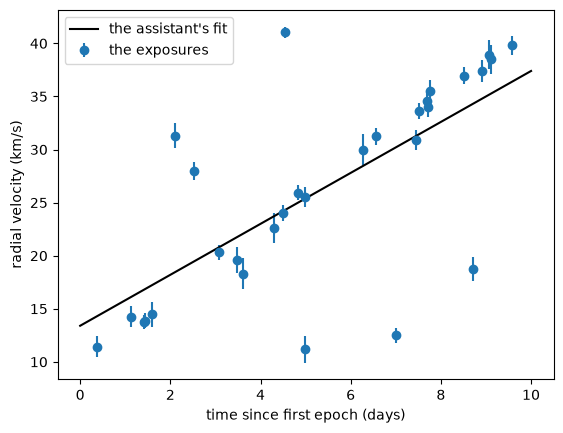

In [1]:
import numpy as np
import matplotlib.pyplot as plt

d = np.genfromtxt('data/demo_data.csv', delimiter=',', names=True)
t, rv, sigma_rv = d['t_days'], d['rv_kms'], d['sigma_rv_kms']

# type in whatever the assistant just told us:
a_ai, v0_ai = 2.40, 13.4   # km/s/day, km/s

plt.errorbar(t, rv, yerr=sigma_rv, fmt='o', label='the exposures')
tg = np.linspace(0, 10, 50)
plt.plot(tg, a_ai * tg + v0_ai, 'k-', label="the assistant's fit")
plt.xlabel('time since first epoch (days)'); plt.ylabel('radial velocity (km/s)'); plt.legend()
plt.show()

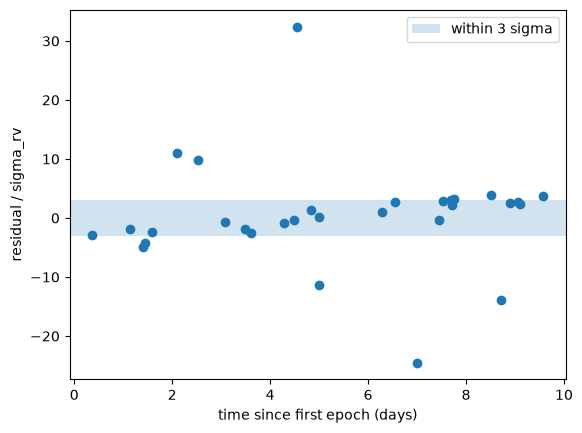

reduced chi-squared of this "fully consistent" fit: 84.1


In [2]:
# The one plot the assistant never showed us: the residuals,
# in units of the error bars the data came with.
z = (rv - (a_ai * t + v0_ai)) / sigma_rv
plt.axhspan(-3, 3, alpha=0.2, label='within 3 sigma')
plt.plot(t, z, 'o')
plt.xlabel('time since first epoch (days)'); plt.ylabel('residual / sigma_rv'); plt.legend()
plt.show()

chi2_red = np.sum(z**2) / (len(t) - 2)
print(f'reduced chi-squared of this "fully consistent" fit: {chi2_red:.1f}')

## So how did it claim the fit was good?

Buried in the middle of its tidy analysis was this step:

> *"If the reduced chi-squared deviates from 1, standard practice is to rescale the measurement uncertainties by a constant factor so that the reduced chi-squared equals unity."*

It multiplied the error bars by whatever number makes the test pass, and then reported passing the test as evidence the model is right.

**That reasoning is circular.** Watch — the same trick makes an *obviously wrong* model "fully consistent" too:

In [3]:
# A deliberately terrible model: no companion at all — constant velocity at the mean.
a_bad, v0_bad = 0.0, rv.mean()
chi2_red_bad = np.sum(((rv - (a_bad * t + v0_bad)) / sigma_rv)**2) / (len(t) - 2)
print(f'no-companion model: reduced chi-squared = {chi2_red_bad:.0f}   (terrible, as it should be)')

scale = np.sqrt(chi2_red_bad)
chi2_rescaled = np.sum(((rv - (a_bad * t + v0_bad)) / (scale * sigma_rv))**2) / (len(t) - 2)
print(f'after "rescaling the uncertainties" by {scale:.1f}: reduced chi-squared = {chi2_rescaled:.2f}')
print('The no-companion model is now "fully consistent with the data" too.')

no-companion model: reduced chi-squared = 136   (terrible, as it should be)
after "rescaling the uncertainties" by 11.6: reduced chi-squared = 1.00
The no-companion model is now "fully consistent with the data" too.


**A test that every model passes is not a test.** The large reduced chi-squared was the data telling us something real — silencing it threw that information away.

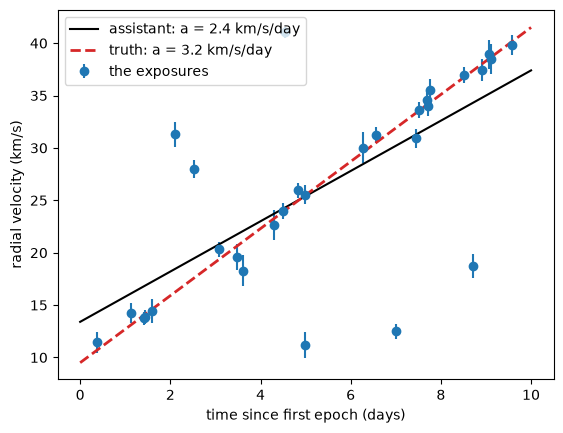

In [4]:
# And here is what I actually put into these data.
a_true, v0_true = 3.2, 9.5   # km/s/day, km/s

plt.errorbar(t, rv, yerr=sigma_rv, fmt='o', label='the exposures')
plt.plot(tg, a_ai * tg + v0_ai, 'k-', label=f"assistant: a = {a_ai} km/s/day")
plt.plot(tg, a_true * tg + v0_true, 'C3--', lw=2, label=f'truth: a = {a_true} km/s/day')
plt.xlabel('time since first epoch (days)'); plt.ylabel('radial velocity (km/s)'); plt.legend()
plt.show()

Six of these thirty exposures are contaminated — the fiber caught the wrong star, or scattered moonlight, and the measured velocity isn't this star's at all. The assistant's pipeline quietly absorbed them. A correct analysis of this dataset (you will be able to do one by October) recovers **a = 3.17 ± 0.07 km/s/day**: the right answer, with error bars sixty times smaller than the assistant's rescaled ones — *and honest*.

## This is not a toy problem

A Sun-like star whose measured velocity drifts steadily, with no companion visible — this is exactly how **Gaia BH1** was found. Careful joint modeling of the radial velocities and astrometry revealed a **9.62 ± 0.18 M☉ black hole** on a 185.6-day orbit: the nearest known black hole (El-Badry et al. 2023, MNRAS 518, 1057).

**And the astronomer who led that discovery is speaking here in two weeks.** Kareem El-Badry gives the Astronomy Colloquium on **Tue Sep 8** (Astronomy Building — details on the department colloquium calendar).

**Extra credit — 5 points on Quiz 1:** attend the colloquium (there will be a signup sheet) *or* watch the recording on YouTube afterward, and turn in at least a page of notes including **two questions you had**, by Noon Tue Sep 15.

## The punchline

The analysis was fluent, complete, error-free-looking — and wrong in a way that mattered.

**Fluent ≠ correct. And you couldn't tell.** *Yet.*

That gap — between an analysis that *looks* right and one that *is* right — is exactly what this course teaches you to close. By December, the flaw you just watched me reveal will take you about thirty seconds to catch on your own.

## What is an error bar, actually?

The assistant reported an acceleration of 2.40 **± 4.30** km/s/day. The correct analysis reports 3.17 **± 0.07**. Same exposures. So what is that ± sign even claiming?

**A 1σ error bar is a promise about frequency**: if you repeated the whole experiment many times, the true value should land inside your quoted interval about **68%** of the time.

Not a vibe. Not "roughly this precise." A testable, quantitative promise — which means we can test it, right now.

<p align="center"><img src="images/xkcd_error_bars.png" alt="xkcd comic: an error bar drawn on an error bar, recursively — a confidence interval with its own confidence intervals" style="display:block;margin:0 auto;max-height:260px"></p>

<small>xkcd #2110 (CC BY-NC 2.5)</small>

In [ ]:
# The experiment, repeated 1000 times: same true line, fresh noise each time,
# honest weighted fit, honest error bars. How often does the truth land inside?
rng = np.random.default_rng(457)

def wls_slope(x, y, s):
    A = np.vstack([x, np.ones_like(x)]).T
    C = np.linalg.inv(A.T @ (A / s[:, None]**2))
    m, b = C @ (A.T @ (y / s**2))
    return m, np.sqrt(C[0, 0])

covered = 0
for _ in range(1000):
    ts = np.sort(rng.uniform(0, 10, 30))
    ss = rng.uniform(0.5, 1.5, 30)
    rvs = a_true * ts + v0_true + rng.normal(0, ss)   # clean exposures this time
    a_hat, a_err = wls_slope(ts, rvs, ss)
    covered += abs(a_hat - a_true) < a_err

print(f'truth inside the +/- 1 sigma interval: {covered/10:.0f}% of experiments (promise: ~68%)')

In [ ]:
# Now sabotage the error bars, both ways, and re-run the same 1000 experiments.
for factor, label in [(3.0, 'inflated 3x (defensive)'), (1/3, 'shrunk 3x (overconfident)')]:
    rng = np.random.default_rng(457)
    covered = 0
    for _ in range(1000):
        ts = np.sort(rng.uniform(0, 10, 30))
        ss = rng.uniform(0.5, 1.5, 30)
        rvs = a_true * ts + v0_true + rng.normal(0, ss)
        a_hat, a_err = wls_slope(ts, rvs, ss)
        covered += abs(a_hat - a_true) < factor * a_err
    print(f'{label:28s}: truth covered {covered/10:.0f}% of the time')

Inflated error bars cover the truth ~100% of the time — a promise so weak it says nothing. Shrunken ones miss constantly — a confident lie. Only calibrated ones mean what they say.

**This is literally how your labs are graded.** Every dataset I hand you has a truth I hold; part of your grade is whether your error bars cover it at the rate they claim. Tiny bars you can't back up lose points. Defensively huge ones lose points. *Calibration is the skill.*

## The verifier's toolkit (a preview of the whole semester)

Five questions to ask of any analysis — yours, a collaborator's, a paper's, a machine's:

1. **Does the model actually describe the data?** Residual diagnostics, goodness of fit, posterior predictive checks *(weeks 2–8)*
2. **Are the uncertainties calibrated?** Coverage, the χ² distribution, what MCMC posteriors do and don't promise *(weeks 4–8)*
3. **What assumptions went in silently?** Weights, independence, Gaussianity, priors — and what breaks when they're wrong *(all semester)*
4. **Is the answer stable?** Perturb the data, the thresholds, the model — does the conclusion survive? *(weeks 8–12)*
5. **Can you rebuild it from scratch?** Simulate data with a known answer and check you recover it — the single most powerful verification trick you will learn *(week 2 onward, and it's in every lab's verification plan)*

You just watched question 1 demolish a fluent analysis in one plot, and question 2 is how you're graded. By December all five are reflexes.

<p align="center"><img src="images/xkcd_curve_fitting.png" alt="xkcd comic: the same scatter plot fit twelve different ways, each caption more desperate than the last" style="display:block;margin:0 auto;max-height:850px"></p>

<small>xkcd #2048 (CC BY-NC 2.5)</small>

## What changed, and what didn't

**Producing a fit is now cheap.** Any assistant will hand you code, plots, and confident prose in seconds.

**Knowing whether the fit is right is still expensive** — it takes statistics, judgment, and checks. That skill did not get automated. It got *more valuable*, because the volume of fluent, unverified analysis in the world just exploded.

By the end of this semester you should be able to:

1. **Apply** existing models in astronomy and interpret the results against the literature.
2. **Identify** when existing models are inadequate, and develop new ones.
3. **Report** inferences with appropriate uncertainties and publication-quality visualizations.
4. **Critically evaluate an analysis produced by someone else — a collaborator, a published paper, or an AI system — and verify or refute its conclusions with quantitative evidence.** ← *new, and the reason this course looks the way it does*

## The arc of the semester

- **Weeks 2–5 — Foundations.** Probability, estimators and their failure modes, maximum likelihood, regression done honestly. *(You'll redo today's demo properly, on your own data.)*
- **Weeks 6–8 — Bayesian inference.** Priors, MCMC, model building, posterior predictive checks. Midterm lands here.
- **Weeks 8–11 — Structured data.** Time series, Gaussian processes, hierarchical models, and inference when you can't even write the likelihood down.
- **Weeks 12–14 — Machine learning.** Trees, clustering, dimensionality reduction, then neural networks and the foundation models running on real surveys.
- **Weeks 15–16 — Closing the loop.** LLMs and AI agents as statistical objects: how they work, how they fail, and how everything above lets you verify them. Capstone talks.

Full schedule with dates and readings: the syllabus, at the top of the repo.

<p align="center"><img src="images/metro_map_data_science.png" alt="A subway-style metro map of data science skills: interconnected lines for statistics, programming, machine learning, visualization, and big data" style="display:block;margin:0 auto;max-height:300px"></p>

<small>The territory, drawn as a subway map (credit: S. Chandrasekaran). This course rides most of these lines.</small>

## Two tracks, one grade

**Track A — live, AI-free.** In-class quizzes and oral defenses. Certifies the statistical reasoning you carry in your own head. No notes, no computation, no AI.

**Track B — open-AI, documented.** Labs, take-home exam components, the capstone. Certifies that you can do — and stand behind — a real analysis under realistic research conditions, which in 2026 include AI tools.

| Component | Weight |
|---|---|
| Labs (roughly weekly, AI-in-the-loop, documented) | 25% |
| In-class quizzes (short, written, AI-free) | 15% |
| Midterm (take-home 12% + oral defense 8%) | 20% |
| Final (take-home 12% + oral defense 8%) | 20% |
| Capstone (notebook, video & lightning talk) | 20% |

Lowest lab and lowest quiz are dropped. You need both tracks to do well; **neither can be delegated to a machine.**

## Your data are yours alone

Every lab hands you a dataset generated *specifically for you*: your data, your noise, your truth — parameters I hold and you cannot look up.

- Your grade depends on recovering values you can't google, **and** on whether your error bars cover the truth at the rate they claim. Calibration is the skill — tiny error bars you can't back up lose points, and so do defensively huge ones.
- Your classmates' datasets have *different* answers. Copying someone's numbers is self-detecting: their truth isn't yours.
- Some labs hand you a complete AI-generated analysis and your job is the referee report: find the flaws, demonstrate them quantitatively, fix them. You just watched me do one.

## What an oral defense sounds like

Short scheduled conversations (5–10 min) with me or the TA about work you submitted. Everyone defends the midterm, final, and capstone; lab defenses rotate, at least two each. The questions are never trick questions — they're the ones any collaborator would ask:

- *"Why that threshold, and what happens if you move it?"*
- *"Which of your checks would have caught it if this number were wrong?"*
- *"What did the AI get wrong, and how did you know?"*

If you did the work, these take zero preparation — you already know the answers, because you made the choices. That's the design: **defenses are easy if and only if the work is yours.**

They're also a rehearsal for every group meeting, seminar, and thesis defense in your future. Before anything is graded, we'll run an **ungraded practice round** in mid-September — I'll defend my own analysis first, then a few volunteers — and the first graded Lab 01 defenses follow right after. Consider yourselves warned, cheerfully.

## Working with AI: the ground rules

Using AI assistants is **allowed and expected** on all labs and take-home exams. The rules, verbatim from the syllabus:

- **Document it.** Every submission includes a short AI-use appendix: which tools, what you asked, what they got wrong, how you found out. "I did not use AI" is a perfectly acceptable appendix, if it's true.
- **You are the author.** You are graded on verification and judgment. Turning in unverified AI output is turning in someone else's work with your name on it.
- **You must be able to defend it.** Any submission can be selected for a short oral defense. If you cannot explain your own submission, it isn't your submission.
- **The line.** Discussing problems with classmates: encouraged. Using AI and documenting it: encouraged. Sharing solutions: cheating. Fabricating your AI-use appendix: cheating, of the referral-to-the-Senate-Committee variety.

## What a useful AI appendix looks like

**Useless (and graded accordingly):**

> *"I used ChatGPT to help with this lab."*

**Useful (this is full marks):**

> *"Asked Copilot to draft the data-loading and plotting boilerplate — kept it after checking the point count matched the file. Asked Claude to explain why my likelihood was returning NaN; its first explanation was wrong (blamed the priors), and I caught that because the NaN appeared even with flat priors. The actual bug was a log of a negative number, which I found from the traceback. No AI was used for the interpretation sections."*

The second one costs you three minutes and demonstrates exactly the skill this course grades: you knew what the machine did, you checked it, and you caught it when it was wrong. **Honesty here is free. Fabrication here is an academic integrity case.**

## Nobody needs to pay for anything

- UIUC gives every student **free access to Microsoft Copilot** — sign in with your illinois.edu account.
- Every assignment in this course is designed to be completable with free-tier tools.
- Paid tools are allowed, never required, and never an advantage in the thing that's actually graded: *your* verification and judgment.

Honest work is deliberately the path of least resistance here: your dataset is yours alone, documented AI use costs you nothing, and defenses are easy *if and only if* you did the work.

## "So why learn statistics at all, then?"

Because **verification IS statistics.**

Everything you'll use to catch a broken analysis — calibration, residual diagnostics, posterior predictive checks, knowing what a reduced chi-squared is allowed to tell you — *is the content of this course*.

And in the last two weeks we close the loop: neural networks → foundation models → large language models *as statistical objects*, verified with the same tools. You will leave able to use the machine **and** to catch it lying.

That combination is the actual job description now — in astronomy and everywhere else.

<p align="center"><img src="images/xkcd_machine_learning.png" alt="xkcd comic: a machine-learning system as a big pile of linear algebra you pour data into and stir until the answers look right" style="display:block;margin:0 auto;max-height:300px"></p>

<small>xkcd #1838 (CC BY-NC 2.5)</small>

## Logistics: how this course runs

- **Everything is on GitHub**, not Canvas: <https://github.com/gnarayan/ast457_2026_Fall>. Fork the repo, make a folder with your name, work there, submit by pull request. (`help/git/` in the repo if this is new to you.)
- **Labs post Thursdays, due the next Wednesday by Noon.** Lab 01 posts Thu Sep 3.
- **Quizzes** (~6, 10–15 min, start of class, roughly every other week; first one Tue Sep 8).
- **Office hours**: me — Astronomy 129, by appointment; Abha — Wednesdays 11:00–noon (or by appointment), over Zoom.
- Some weeks I'm traveling — class will be led by a substitute or held on Zoom; watch your email. The syllabus (repo top level, PDF + accessible Markdown) has the full schedule.
- Texts: Ivezić et al. (**ICVG**) and VanderPlas (**VdP**) — both free online through the library / GitHub; details in the syllabus.

<p align="center"><img src="images/repo_qr.png" alt="QR code linking to https://github.com/gnarayan/ast457_2026_Fall" width="150" style="display:block;margin:0 auto;"></p>

<p align="center"><small>Scan to open the course repo</small></p>

<p align="center"><img src="images/xkcd_git.png" alt="xkcd comic: git described as a beautiful distributed graph theory tree model, used by memorizing a few shell commands" style="display:block;margin:0 auto;max-height:280px"></p>

<small>xkcd #1597 (CC BY-NC 2.5) — we will teach you enough git that this is not you</small>

## Before Thursday: get your environment working

Thursday is a hands-on Python + plotting crash course. Come with a laptop that has the course environment installed:

1. Follow **`INSTALL.txt`** at the top of the course repo (Miniforge + a conda env called `astr457`).
2. Launch `jupyter lab` and confirm you can open a notebook with the `astr457` kernel.
3. Optional but smart: the ten-question **prerequisite self-check** (`lecture/01/prereq_selfcheck.md`) — self-scored, never collected; every item points at the exact refresher to use if it feels shaky.
4. If you get stuck: `help/` in the repo has Python, Unix, and git cheat sheets — and email me *before* Thursday, not during.

<p align="center"><img src="images/xkcd_python.png" alt="xkcd comic: a stick figure flying after typing import antigravity in Python" style="display:block;margin:0 auto;max-height:320px"></p>

<small>xkcd #353 (CC BY-NC 2.5)</small>

**Questions?**